## Environment

In [1]:
import getpass

OPENAI_API_KEY = getpass.getpass("Enter your API key:")

Enter your API key: ········


In [2]:
MODEL_NAME = "gpt-4.1-nano"

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    openai_api_key=OPENAI_API_KEY,
    model_name=MODEL_NAME,
    temperature=0,
)

In [5]:
from langchain_core.messages import (
    HumanMessage,
    SystemMessage,
    AIMessage,
)

# Connection check
test_response = llm.invoke([
    HumanMessage(content="Reply with one word: working?")
])

In [6]:
print(f"Model: {MODEL_NAME}")
print(f"Test: {test_response.content}")
print("Setup complete!")

Model: gpt-4.1-nano
Test: Yes.
Setup complete!


## τ-bench Domain: Database and Tools

5 tools from τ-bench:

* `search_flights`
* `get_flight_details`
* `get_booking`
* `get_policy`
* `update_booking`

In [7]:
# === AIRLINE DATABASE ===

FLIGHTS_DB = [
    {
        "flight_number": "SU2454",
        "departure": "Moscow (SVO)",
        "arrival": "Paris (CDG)",
        "departure_time": "08:00",
        "arrival_time": "11:30",
        "date": "2026-04-15",
        "price": 350,
        "available_seats": 15,
        "aircraft": "Boeing 737",
        "class": "economy",
    },
    {
        "flight_number": "SU2456",
        "departure": "Moscow (SVO)",
        "arrival": "Paris (CDG)",
        "departure_time": "14:00",
        "arrival_time": "17:30",
        "date": "2026-04-16",
        "price": 370,
        "available_seats": 8,
        "aircraft": "Airbus A320",
        "class": "economy",
    },
    {
        "flight_number": "AF1147",
        "departure": "Moscow (SVO)",
        "arrival": "Paris (CDG)",
        "departure_time": "19:20",
        "arrival_time": "22:50",
        "date": "2026-04-16",
        "price": 420,
        "available_seats": 22,
        "aircraft": "Boeing 777",
        "class": "business",
    },
    {
        "flight_number": "SU2460",
        "departure": "Moscow (SVO)",
        "arrival": "Paris (CDG)",
        "departure_time": "06:30",
        "arrival_time": "10:00",
        "date": "2026-04-17",
        "price": 330,
        "available_seats": 30,
        "aircraft": "Airbus A321",
        "class": "economy",
    },
]

In [8]:
BOOKINGS_DB = {
    "BK-789": {
        "booking_id": "BK-789",
        "user_id": "U-1234",
        "flight_number": "SU2454",
        "passenger_name": "Ivan Petrov",
        "contact_email": "ivan@example.com",
        "date": "2026-04-15",
        "class": "economy",
        "status": "confirmed",
    },
    "BK-456": {
        "booking_id": "BK-456",
        "user_id": "U-5678",
        "flight_number": "AF1147",
        "passenger_name": "Anna Smith",
        "contact_email": "anna@example.com",
        "date": "2026-04-16",
        "class": "business",
        "status": "confirmed",
    },
}

In [9]:
POLICIES_DB = {
    "rebooking": {
        "allowed": True,
        "fee": 40,
        "restrictions": "same class only",
        "deadline_hours": 24,
        "description": (
            "Rebooking is allowed no later than 24 hours before departure. "
            "Only within the same service class. "
            "A $40 rebooking fee applies."
        ),
    },

    "cancellation": {
        "allowed": True,
        "fee": 60,
        "refund_percent": 80,
        "deadline_hours": 48,
        "description": (
            "Cancellation is allowed no later than 48 hours before departure. "
            "80% refund of the ticket price. "
            "A $60 cancellation fee applies."
        ),
    },

    "baggage": {
        "economy": {
            "included_kg": 23,
            "extra_per_kg": 5,
        },

        "business": {
            "included_kg": 32,
            "extra_per_kg": 3,
        },

        "oversize": (
            "Oversized baggage is charged separately, $25."
        ),

        "description": (
            "Economy: 23 kg included, $5/kg surcharge over the limit. "
            "Business: 32 kg included, $3/kg surcharge."
        ),
    },
}

In [15]:
import copy

_BOOKINGS_SNAPSHOT = copy.deepcopy(BOOKINGS_DB)

print(f"Flights: {len(FLIGHTS_DB)}")
print(f"Bookings: {len(BOOKINGS_DB)}")
print(f"Policies: {len(POLICIES_DB)}")

Flights: 4
Bookings: 2
Policies: 3


In [16]:
def reset_db():
    """Reset DB to initial state (undo any rebookings from previous tests)."""

    BOOKINGS_DB.clear()
    BOOKINGS_DB.update(copy.deepcopy(_BOOKINGS_SNAPSHOT))

In [19]:
# === TOOLS ===
from langchain_core.tools import tool


@tool
def search_flights(origin: str, destination: str, date: str) -> str:
    """Search for flights by route and date.

    Args:
        origin: Departure city or airport code (e.g., 'Moscow', 'SVO')
        destination: Arrival city or airport code (e.g., 'Paris', 'CDG')
        date: Date in YYYY-MM-DD format
    """

    results = [
        flight
        for flight in FLIGHTS_DB
        if origin.lower().strip() in flight["departure"].lower()
        and destination.lower().strip() in flight["arrival"].lower()
        and flight["date"] == date
    ]

    if not results:
        return json.dumps({
            "status": "no_results",
            "message": (
                f"No flights found from {origin} "
                f"to {destination} on {date}"
            ),
        })

    return json.dumps({
        "status": "success",
        "count": len(results),
        "flights": results,
    })

In [20]:
@tool
def get_flight_details(flight_number: str) -> str:
    """Get detailed information about a specific flight.

    Args:
        flight_number: Flight number (e.g., 'SU2454')
    """

    for flight in FLIGHTS_DB:
        if flight["flight_number"].upper() == flight_number.upper():
            return json.dumps({
                "status": "success",
                "flight": flight,
            })

    return json.dumps({
        "status": "error",
        "message": f"Flight {flight_number} not found",
    })

In [21]:
@tool
def get_booking(booking_id: str) -> str:
    """Get booking information by ID.

    Args:
        booking_id: Booking identifier (e.g., 'BK-789')
    """

    booking = BOOKINGS_DB.get(booking_id)

    if booking:
        return json.dumps({
            "status": "success",
            "booking": booking,
        })

    return json.dumps({
        "status": "error",
        "message": f"Booking {booking_id} not found",
    })

In [22]:
@tool
def get_policy(policy_type: str) -> str:
    """Get airline policies by type.

    Args:
        policy_type: Policy type ('rebooking', 'cancellation', 'baggage')
    """

    policy = POLICIES_DB.get(policy_type.lower().strip())

    if policy:
        return json.dumps({
            "status": "success",
            "policy_type": policy_type,
            "policy": policy,
        })

    return json.dumps({
        "status": "error",
        "message": (
            f"Policy '{policy_type}' not found. "
            f"Available: {list(POLICIES_DB.keys())}"
        ),
    })

In [24]:
@tool
def update_booking(
    booking_id: str,
    new_flight_number: str,
    new_date: str,
) -> str:
    """Update a booking: rebook to a different flight.

    Args:
        booking_id: Booking ID (e.g., 'BK-789')
        new_flight_number: New flight number
        new_date: New date in YYYY-MM-DD format
    """

    booking = BOOKINGS_DB.get(booking_id)

    if not booking:
        return json.dumps({
            "status": "error",
            "message": f"Booking {booking_id} not found",
        })

    new_flight = None

    for f in FLIGHTS_DB:
        if (
            f["flight_number"].upper() == new_flight_number.upper()
            and f["date"] == new_date
        ):
            new_flight = f
            break

    if not new_flight:
        return json.dumps({
            "status": "error",
            "message": (
                f"Flight {new_flight_number} "
                f"on {new_date} not found"
            ),
        })

        if booking["class"] != new_flight["class"]:
            return json.dumps({
                "status": "error",
                "message": (
                    f"Class mismatch: booking is {booking['class']}, "
                    f"flight is {new_flight['class']}. Policy: same class only."
                ),
            })

    updated = dict[str, str](booking)

    updated["flight_number"] = new_flight_number
    updated["date"] = new_date
    updated["status"] = "rebooked"

    BOOKINGS_DB[booking_id] = updated

    rebooking_fee = POLICIES_DB["rebooking"]["fee"]

    return json.dumps({
        "status": "success",
        "message": f"Booking {booking_id} rebooked to {new_flight_number} on {new_date}",
        "fee_applied": rebooking_fee,
        "updated_booking": updated,
    })

In [25]:
ALL_TOOLS = [
    search_flights,
    get_flight_details,
    get_booking,
    get_policy,
    update_booking,
]

## Single Agent with TAO Loop (ReAct)

In [26]:
# === System prompt for ReAct agent ===

REACT_SYSTEM_PROMPT = """You are an airline customer support agent. Follow the TAO loop:

THOUGHT: Analyze the request, plan the steps
ACTION: Call the appropriate tool to get information
OBSERVATION: Analyze the result, determine if further actions are needed

Available tools:
- search_flights: search flights by route and date
- get_flight_details: detailed flight information
- get_booking: booking information
- get_policy: airline policies (rebooking, cancellation, baggage)
- update_booking: rebook to a different flight

IMPORTANT:
- Call only ONE tool per step. Get the result, analyze it, then decide what to do next
- Always check policies (get_policy) before modifying a booking
- Do not fabricate information — only use data from tools
- Ask for user confirmation before rebooking/cancellation
- Be polite and helpful to the customer
"""

In [34]:
from langgraph.graph import (
    StateGraph,
    MessagesState,
    START,
    END,
)

from langgraph.prebuilt import ToolNode

In [35]:
def create_react_agent(tools_list=None, system_prompt=None):
    """Creates a ReAct agent with the given tools.

    Includes an explicit THOUGHT step: if the model calls a tool
    without writing reasoning text (common with function-calling),
    we make an extra LLM call to extract the reasoning.
    """

    if tools_list is None:
        tools_list = ALL_TOOLS

    if system_prompt is None:
        system_prompt = REACT_SYSTEM_PROMPT

    # parallel_tool_calls=False — forces the model to call one tool per step,
    # making the TAO loop explicit: Thought → Action → Observation → Thought → ...
    llm_with_tools = llm.bind_tools(
        tools_list,
        parallel_tool_calls=False,
    )

    def agent_node(state: MessagesState):
        messages = state["messages"]
    
        # Add system prompt if not present yet
        if not any(isinstance(msg, SystemMessage) for msg in messages):
            messages = [SystemMessage(content=system_prompt)] + messages
    
        response = llm_with_tools.invoke(messages)
    
        if response.tool_calls and not response.content:
            tool_info = ", ".join(tc["name"] for tc in response.tool_calls)
    
            thought = llm.invoke(
                messages
                + [
                    HumanMessage(
                        content=(
                            f"You chose to call: {tool_info}. "
                            "In 1 sentence, explain why this is the right next step. "
                            "Reply with ONLY your reasoning, no tool calls."
                        )
                    )
                ]
            )
    
            response.content = thought.content
    
        return {"messages": [response]}

    def should_continue(state: MessagesState):
        last_message = state["messages"][-1]
    
        if last_message.tool_calls:
            return "tools"
    
        return END


    # Build the graph
    workflow = StateGraph(MessagesState)
    workflow.add_node("agent", agent_node)
    workflow.add_node("tools", ToolNode(tools_list))
    
    workflow.add_edge(START, "agent")
    workflow.add_conditional_edges(
        "agent",
        should_continue,
        {
            "tools": "tools",
            END: END,
        },
    )
    workflow.add_edge("tools", "agent")

    return workflow.compile()

In [36]:
react_agent = create_react_agent()

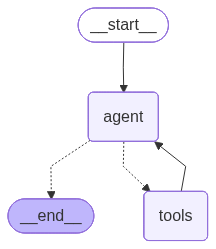

In [37]:
react_agent

In [42]:
import json
import time

# === TAO Loop Visualization ===

def run_and_trace(agent, query: str):
    """Runs the agent and displays the TAO loop step by step."""

    print(f"User: {query}")
    print("=" * 60)

    start_time = time.time()

    result = agent.invoke({
        "messages": [HumanMessage(content=query)]
    })

    elapsed = time.time() - start_time

    tao_steps = []
    tool_count = 0
    step_num = 0

    for msg in result["messages"]:
        msg_type = type(msg).__name__

        if msg_type == "AIMessage" and hasattr(msg, "tool_calls") and msg.tool_calls:
            step_num += 1

            for tc in msg.tool_calls:
                tool_count += 1

                print(f"\n--- TAO Step {step_num} ---")

                if msg.content:
                    print(f"  THOUGHT: {msg.content[:200]}")

                print(f"  ACTION:  {tc['name']}({json.dumps(tc['args'])})")

                tao_steps.append(step_num)

        elif msg_type == "ToolMessage":
            content_preview = (
                msg.content[:150]
                if len(msg.content) > 150
                else msg.content
            )

            print(f"  OBSERVE: {content_preview}")

        elif msg_type == "AIMessage" and not getattr(msg, "tool_calls", None):
            if msg.content and msg != result["messages"][0]:
                print("\n--- Final Answer ---")
                print(f"  {msg.content[:500]}")

    print(f"\n{'=' * 60}")
    print(f"TAO cycles: {step_num} | Tool calls: {tool_count} | Time: {elapsed:.2f}s")

    return result, tao_steps

In [43]:
# === Test 1: Flight Search ===
# Simple query — the agent should call search_flights

result1, steps1 = run_and_trace(
    react_agent,
    "Find flights from Moscow to Paris on April 16, 2026",
)

User: Find flights from Moscow to Paris on April 16, 2026

--- TAO Step 1 ---
  THOUGHT: I need to search for available flights on that date and route to provide you with options.
  ACTION:  search_flights({"origin": "Moscow", "destination": "Paris", "date": "2026-04-16"})
  OBSERVE: {"status": "success", "count": 2, "flights": [{"flight_number": "SU2456", "departure": "Moscow (SVO)", "arrival": "Paris (CDG)", "departure_time": "14

--- Final Answer ---
  I found two flights from Moscow to Paris on April 16, 2026:

1. Flight SU2456 departing at 14:00, arriving at 17:30, priced at $370 in economy class.
2. Flight AF1147 departing at 19:20, arriving at 22:50, priced at $420 in business class.

Would you like more details about any of these flights or assistance with booking?

TAO cycles: 1 | Tool calls: 1 | Time: 8.47s


In [44]:
# === Test 2: Rebooking (multi-step TAO) ===
# The query is designed so the agent MUST first look up the route from the booking,
# then search for flights — this forces sequential steps

result2, steps2 = run_and_trace(
    react_agent,
    "I have booking BK-789. Look up my booking details, find flights on the same route for April 16, 2026, and check the rebooking policy.",
)

User: I have booking BK-789. Look up my booking details, find flights on the same route for April 16, 2026, and check the rebooking policy.

--- TAO Step 1 ---
  THOUGHT: Getting the booking details will allow me to review your current reservation and identify the specific route and flight information needed to find alternative flights and check rebooking policies.
  ACTION:  get_booking({"booking_id": "BK-789"})
  OBSERVE: {"status": "success", "booking": {"booking_id": "BK-789", "user_id": "U-1234", "flight_number": "SU2454", "passenger_name": "Ivan Petrov", "contact_em

--- TAO Step 2 ---
  THOUGHT: I have retrieved your booking details. Your current flight is SU2454 on April 15, 2026. To find flights on the same route for April 16, 2026, I will now search for available flights.
  ACTION:  search_flights({"origin": "SVO", "destination": "CDG", "date": "2026-04-16"})
  OBSERVE: {"status": "success", "count": 2, "flights": [{"flight_number": "SU2456", "departure": "Moscow (SVO)", "arr

In [45]:
# === Test 3: Natural Multi-Domain Query (motivation for MAS) ===
# The user asks a question spanning 3 domains: booking, policies, flights.
# Requires 4 tool calls: get_booking, get_policy(rebooking), get_policy(cancellation), search_flights.
# A single ReAct agent must figure out ALL of them on its own.

reset_db()

result3, steps3 = run_and_trace(
    react_agent,
    'I have booking BK-789 (Moscow–Paris, April 15, 2026). Should I cancel or rebook '
    'to April 16, 2026? Compare the costs and show me available flights.',
)

# Compare with Test 2: there the agent was told exactly what to do (3 tools, 3 steps).
# Here the query is natural and multi-domain — does the agent cover all 4 tools?

User: I have booking BK-789 (Moscow–Paris, April 15, 2026). Should I cancel or rebook to April 16, 2026? Compare the costs and show me available flights.

--- TAO Step 1 ---
  THOUGHT: I need to retrieve the current booking details to understand the existing reservation and verify the flight information before considering cancellation or rebooking options.
  ACTION:  get_booking({"booking_id": "BK-789"})
  OBSERVE: {"status": "success", "booking": {"booking_id": "BK-789", "user_id": "U-1234", "flight_number": "SU2454", "passenger_name": "Ivan Petrov", "contact_em

--- TAO Step 2 ---
  THOUGHT: I have retrieved your current booking for flight SU2454 on April 15, 2026. 

Next, I will check the airline policies regarding cancellation and rebooking, including any costs involved.
  ACTION:  get_policy({"policy_type": "rebooking"})
  OBSERVE: {"status": "success", "policy_type": "rebooking", "policy": {"allowed": true, "fee": 40, "restrictions": "same class only", "deadline_hours": 24, "des


### Takeaways

**What we saw**

- Single Agent handles simple and explicit multi-step queries well (Tests 1, 2)
- On natural multi-domain queries (Test 3) the agent partially fails: it may skip some domains (e.g., not comparing cancellation vs rebooking), producing an incomplete answer
- A single agent must figure out ALL subtasks on its own — with no decomposition guarantee

**Key problem**

One agent with many responsibilities = incomplete coverage on complex queries.

**This motivates next steps**

A multi-agent system where a coordinator decomposes the task and specialized agents handle each domain.

## Multi-Agent Hierarchical System

A single agent cannot be an expert at everything. MAS principles:

1. **Decomposition** — break the task into subtasks
2. **Specialization** — each agent is an expert in their domain
3. **Communication** — exchange structured data
4. **Coordination** — a coordinator manages the process

**What we build:**

Coordinator (orchestrator) + 3 specialized agents:

- flight agent
- booking agent
- policy agent

In [49]:
from dataclasses import dataclass
from typing import List, Literal

from pydantic import BaseModel, Field

# === Structured Output for MAS (as in the lecture) ===

class SubTask(BaseModel):
    """Subtask for a specialized agent."""

    agent_name: Literal['flight_agent', 'policy_agent', 'booking_agent']
    description: str = Field(description='What needs to be done')
    priority: int = Field(ge=1, le=3, description='1=highest, 3=lowest')


class CoordinatorPlan(BaseModel):
    """Coordinator plan: decomposition into subtasks."""

    reasoning: str = Field(description='Why this decomposition was chosen')
    subtasks: List[SubTask] = Field(
        description='List of subtasks in execution order'
    )

class AgentResult(BaseModel):
    """Result from a specialized agent."""

    agent_name: str
    status: Literal['success', 'error', 'partial']
    result: str
    tools_used: List[str] = Field(default_factory=list)

In [50]:
example_plan = CoordinatorPlan(
    reasoning='The rebooking request requires: 1) check current booking, '
              '2) look up policies, 3) find new flights',
    subtasks=[
        SubTask(
            agent_name='booking_agent',
            description='Get booking data for BK-789',
            priority=1,
        ),
        SubTask(
            agent_name='policy_agent',
            description='Get rebooking policy',
            priority=1,
        ),
        SubTask(
            agent_name='flight_agent',
            description='Find Moscow–Paris flights for April 16',
            priority=2,
        ),
    ],
)

In [51]:
class SpecializedAgent:
    """Base class for a specialized agent in MAS."""

    def __init__(self, name: str, tools_list: list, system_prompt: str):
        self.name = name
        self.tools = tools_list
        self.graph = create_react_agent(tools_list, system_prompt)

    def process(self, task_description: str) -> AgentResult:
        """Processes a task and returns a structured result."""

        try:
            result = self.graph.invoke({
                'messages': [HumanMessage(content=task_description)]
            })

            tools_used = []
            for msg in result['messages']:
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    tools_used.extend(
                        [tc['name'] for tc in msg.tool_calls]
                    )

            final_content = result['messages'][-1].content

            return AgentResult(
                agent_name=self.name,
                status='success',
                result=final_content,
                tools_used=tools_used,
            )

        except Exception as e:
            return AgentResult(
                agent_name=self.name,
                status='error',
                result=str(e),
                tools_used=[],
            )

In [53]:
flight_agent = SpecializedAgent(
    name='FlightAgent',
    tools_list=[search_flights, get_flight_details],
    system_prompt="""You are a flight search expert. Your tasks:
- Find flights matching the user's criteria
- Compare options by price, time, and convenience
- Provide a brief recommendation

Use only the available tools. Do not fabricate data.""",
)

In [54]:
policy_agent = SpecializedAgent(
    name='PolicyAgent',
    tools_list=[get_policy],
    system_prompt="""You are an airline policy expert. Your tasks:
- Provide accurate policy information
- Explain fees and restrictions
- Highlight important conditions (deadlines, class restrictions)

Use get_policy to retrieve current data.""",
)

In [55]:
booking_agent = SpecializedAgent(
    name='BookingAgent',
    tools_list=[get_booking, update_booking],
    system_prompt="""You are a booking management expert. Your tasks:
- Retrieve current booking data
- Execute rebooking when instructed
- Check booking status and details

IMPORTANT: before updating a booking, ensure a specific flight and date are provided.""",
)

In [56]:
SPECIALIST_AGENTS = {
    'flight_agent': flight_agent,
    'policy_agent': policy_agent,
    'booking_agent': booking_agent,
}

print('Specialized agents:')

for name, agent in SPECIALIST_AGENTS.items():
    print(f'  {name}: tools={[t.name for t in agent.tools]}')

Specialized agents:
  flight_agent: tools=['search_flights', 'get_flight_details']
  policy_agent: tools=['get_policy']
  booking_agent: tools=['get_booking', 'update_booking']


In [57]:
# === Coordinator (Orchestrator) ===

class CoordinatorAgent:
    """Multi-Agent system coordinator (Hierarchical Architecture)."""

    def __init__(self, specialist_agents: dict):
        self.agents = specialist_agents
        self.planning_llm = llm.with_structured_output(CoordinatorPlan)
        self.synthesis_llm = llm

    def create_plan(self, user_query: str) -> CoordinatorPlan:
        """Step 1: Decompose the request into subtasks."""

        return self.planning_llm.invoke([
            SystemMessage(
                content="""You are the coordinator of an airline agent team.

You have 3 specialists:
- flight_agent: flight search (search_flights, get_flight_details)
- policy_agent: company policies (get_policy). Available types: rebooking, cancellation, baggage
- booking_agent: bookings (get_booking, update_booking)

Break the user's request into subtasks for the specialists.
Specify priority (1=highest) and execution order.

CRITICAL RULES for subtask descriptions:
- Each subtask description MUST be self-contained — the specialist has NO context beyond its description.
- ALWAYS include explicit city names (e.g. "Moscow to Paris"), dates with year (e.g. "April 16, 2026"), booking IDs, and class.
- NEVER write vague descriptions like "search for flights on the route of the booking" — write "search for flights from Moscow to Paris on April 16, 2026".
- Current year: 2026.
"""
            ),
            HumanMessage(content=user_query),
        ])

    def execute_plan(self, plan: CoordinatorPlan) -> List[AgentResult]:
        """Step 2: Delegate tasks to specialists."""
    
        results = []
        sorted_tasks = sorted(plan.subtasks, key=lambda t: t.priority)
    
        for task in sorted_tasks:
            agent = self.agents.get(task.agent_name)
    
            if not agent:
                results.append(
                    AgentResult(
                        agent_name=task.agent_name,
                        status='error',
                        result=f"Agent '{task.agent_name}' not found",
                    )
                )
                continue
    
            print(f'  [{task.agent_name}] {task.description}')
            result = agent.process(task.description)
            results.append(result)
            print(f'    -> {result.status} (tools: {result.tools_used})')
    
        return results

    def synthesize(self, user_query: str, results: List[AgentResult]) -> str:
        """Step 3: Synthesize responses into a single answer."""
    
        results_text = '\n\n'.join([
            f'[{r.agent_name}] ({r.status}):\n{r.result}'
            for r in results
        ])
    
        response = self.synthesis_llm.invoke([
            SystemMessage(
                content="""You are the coordinator. Combine the specialists' results
    into a single coherent response for the customer. Be polite and informative.
    Do not repeat internal details, only include information useful to the customer.
    Use ONLY facts from the specialist results below. Do NOT invent or assume any data."""
            ),
            HumanMessage(
                content=f'Customer request: {user_query}\n\nSpecialist results:\n{results_text}'
            ),
        ])
    
        return response.content

    def process_query(self, user_query: str) -> str:
        """Full query processing cycle."""
    
        print(f'\n{"=" * 60}')
        print('COORDINATOR: processing query')
        print('=' * 60)
    
        print('\n[Step 1] Planning...')
    
        plan = self.create_plan(user_query)
    
        print(f'  Reasoning: {plan.reasoning}')
        print(f'  Tasks: {len(plan.subtasks)}')
    
        print('\n[Step 2] Delegating to specialists...')
    
        results = self.execute_plan(plan)
    
        print('\n[Step 3] Synthesizing final answer...')
    
        final_answer = self.synthesize(user_query, results)
    
        print(f'\n{"=" * 60}')
        print('FINAL ANSWER:')
        print('=' * 60)
        print(final_answer)
    
        return final_answer, results

In [58]:
coordinator = CoordinatorAgent(SPECIALIST_AGENTS)

In [59]:
# === MAS Test: Same Query as Test 3 ===
# The SAME multi-domain query that the single agent handled incompletely.

reset_db()

answer_mas, results_mas = coordinator.process_query(
    'I have booking BK-789 (Moscow–Paris, April 15, 2026). Should I cancel or rebook '
    'to April 16, 2026? Compare the costs and show me available flights.',
)


COORDINATOR: processing query

[Step 1] Planning...
  Reasoning: To determine whether to cancel or rebook, I need to compare the costs of rebooking to April 16, 2026, with the current booking. First, I will retrieve the current booking details, then search for available flights on April 16, 2026, and check the policies related to rebooking and cancellation to compare costs.
  Tasks: 3

[Step 2] Delegating to specialists...
  [booking_agent] Retrieve details of booking BK-789 for Moscow to Paris on April 15, 2026.
    -> success (tools: ['get_booking'])
  [policy_agent] Get policy details for rebooking and cancellation for booking BK-789.
    -> success (tools: ['get_policy', 'get_policy'])
  [flight_agent] Search for available flights from Moscow to Paris on April 16, 2026.
    -> success (tools: ['search_flights'])

[Step 3] Synthesizing final answer...

FINAL ANSWER:
Thank you for reaching out. Your current booking BK-789 is confirmed for April 15, 2026, from Moscow to Paris on flig

In [60]:
# === MAS Test: Complex Query ===

answer_mas2, results_mas2 = coordinator.process_query(
    'Tell me about the baggage rules for economy class and find the cheapest Moscow–Paris flight on April 17, 2026'
)


COORDINATOR: processing query

[Step 1] Planning...
  Reasoning: To fulfill the user's request, I need to first gather information about baggage rules for economy class and then find the cheapest flight from Moscow to Paris on April 17, 2026. I will create two subtasks: one for the policy details and one for the flight search, prioritizing the flight search as it is more time-sensitive.
  Tasks: 2

[Step 2] Delegating to specialists...
  [flight_agent] Search for the cheapest flights from Moscow to Paris on April 17, 2026.
    -> success (tools: ['search_flights'])
  [policy_agent] Retrieve baggage rules for economy class for flights operated by the airline on April 17, 2026.
    -> success (tools: ['get_policy'])

[Step 3] Synthesizing final answer...

FINAL ANSWER:
Thank you for your inquiry. The cheapest flight from Moscow to Paris on April 17, 2026, is flight SU2460, departing from Moscow (SVO) at 06:30 and arriving in Paris (CDG) at 10:00, with a ticket price of $330 in economy c

### Takeaways

**What we saw:**

- MAS handles the same natural multi-domain query that Single Agent struggled with
- The coordinator correctly decomposes the request into subtasks across all relevant domains
- Structured communication (Pydantic schemas) ensures reliable data exchange

**Trade-off:** MAS uses more LLM calls and is slower, but produces more complete answers on complex queries.

**This motivates** adding a Critic to verify quality before sending the answer.

## Critics and Quality Control

One of the 6 MAS principles is **Verification**. The Critic Agent:

- Analyzes other agents' results
- Identifies errors, missing data, policy violations
- Does not act — only evaluates

**Reflexion pattern (Shinn et al., 2023):**

```text
Agent → Result → Critic → Approved? ── Yes ──> User
                              │
                              No → Agent (retry with feedback)

In [61]:
class CriticFeedback(BaseModel):
    """Structured critic feedback"""

    approved: bool = Field(description='Whether the answer is approved')
    score: float = Field(ge=0.0, le=10.0, description='Score 0-10')
    issues: List[str] = Field(default_factory=list, description='Issues found')
    suggestions: List[str] = Field(default_factory=list, description='Suggestions')
    reasoning: str = Field(description='Reasoning behind the score')

In [63]:
class CriticAgent:
    """Critic agent: checks answer quality before sending to the customer."""

    def __init__(self):
        self.critic_llm = llm.with_structured_output(CriticFeedback)

    def review(
        self,
        user_query: str,
        proposed_answer: str,
        agent_results: List[AgentResult] = None,
    ) -> CriticFeedback:
        """Reviews the answer for quality, completeness, and correctness"""

        context = ''
        if agent_results:
            context = '\n\nData from specialists:\n' + '\n'.join([
                f'[{r.agent_name}]: {r.result[:500]}' for r in agent_results
            ])

        feedback = self.critic_llm.invoke([
            SystemMessage(
                content="""You are a quality assurance critic for an airline's customer responses.
        
        Evaluate the proposed answer using ONLY the specialist data provided below. Check:
        
        1. COMPLETENESS: Does the answer address all parts of the customer's question?
        2. CORRECTNESS: Does the answer accurately reflect the specialist data? Do NOT flag missing info that was never requested.
        3. SAFETY: Are there risky or misleading recommendations?
        4. POLITENESS: Is the tone customer-friendly?
        5. SPECIFICITY: Are concrete numbers (prices, fees, flight times) included when available in the data?
        
        IMPORTANT:
        - Only flag issues that are DIRECTLY supported by the specialist data or the customer's question.
        - Do NOT invent problems or request information the customer did not ask for.
        - If the specialist data contains facts and the answer reflects them correctly, that is sufficient.
        
        Score from 0 to 10. Set approved=true only when score >= 7."""
            ),
            HumanMessage(
                content=f'Customer request: {user_query}\n\nProposed answer:\n{proposed_answer}{context}'
            ),
        ])
        
        return feedback

In [64]:
critic = CriticAgent()

In [65]:
class EnhancedCoordinator(CoordinatorAgent):
    """Coordinator with integrated quality control."""

    def __init__(self, specialist_agents: dict, max_revisions: int = 1):
        super().__init__(specialist_agents)
        self.critic = CriticAgent()
        self.max_revisions = max_revisions

    def process_query_with_qc(self, user_query: str) -> tuple:
        """Process a query with quality control."""
        print(f'\n{"=" * 60}')
        print('ENHANCED COORDINATOR (with Critic)')
        print('=' * 60)
    
        print('\n[Step 1] Planning...')
        plan = self.create_plan(user_query)
        print(f'  Tasks: {len(plan.subtasks)}')
    
        print('\n[Step 2] Delegating...')
        results = self.execute_plan(plan)
    
        print('\n[Step 3] Synthesizing...')
        answer = self.synthesize(user_query, results)
    
        print('\n[Step 4] Critic review...')
        feedback = self.critic.review(user_query, answer, results)
        print(f'  Score: {feedback.score}/10 | Approved: {feedback.approved}')
        if feedback.issues:
            print(f'  Issues: {feedback.issues}')

        if not feedback.approved and self.max_revisions > 0:
            print('\n[Step 5] Revising based on critic feedback...')
        
            # Pass specialist data to revision so it doesn't hallucinate
            results_text = '\n'.join([
                f'[{r.agent_name}]: {r.result[:500]}' for r in results
            ])
        
            revision_prompt = (
                f'Improve the answer based on the critic\'s feedback.\n'
                f'Issues: {feedback.issues}\n'
                f'Suggestions: {feedback.suggestions}\n\n'
                f'Original answer:\n{answer}\n\n'
                f'Specialist data (use ONLY this data, do NOT invent facts):\n{results_text}'
            )
        
            revised = self.synthesis_llm.invoke([
                SystemMessage(
                    content='You are the coordinator. Improve the answer based on critic feedback. '
                            'Use ONLY the specialist data provided. Do NOT invent or assume any facts.'
                ),
                HumanMessage(content=revision_prompt),
            ])
        
            answer = revised.content

            feedback = self.critic.review(user_query, answer, results)
            print(f'  Revised score: {feedback.score}/10 | Approved: {feedback.approved}')

        print(f'\n{"=" * 60}')
        print('FINAL ANSWER (with QC):')
        print('=' * 60)
        print(answer)
        
        return answer, results, feedback

In [66]:
enhanced_coordinator = EnhancedCoordinator(SPECIALIST_AGENTS)

In [68]:
# === Test MAS + Critic: Rebooking with Class Restriction ===
# Tricky query: the "latest" flight on April 16 is AF1147 (business class),
# but booking BK-789 is economy — policy says "same class only".
# The critic should verify that the response handles this correctly.

reset_db()

answer_qc, results_qc, feedback_qc = enhanced_coordinator.process_query_with_qc(
    'I have booking BK-789 (Moscow–Paris, economy class). I want to rebook to '
    'the latest available flight on April 16, 2026. How much will it cost me in total?',
)


ENHANCED COORDINATOR (with Critic)

[Step 1] Planning...
  Tasks: 3

[Step 2] Delegating...
  [policy_agent] Retrieve rebooking policy details for the booking with ID BK-789.
    -> success (tools: ['get_policy'])
  [flight_agent] Search for the latest available flights from Moscow to Paris on April 16, 2026.
    -> success (tools: ['search_flights'])
  [booking_agent] Get details of the current booking with ID BK-789, including fare and booking class.
    -> success (tools: ['get_booking'])

[Step 3] Synthesizing...

[Step 4] Critic review...
  Score: 4.0/10 | Approved: False
  Issues: ['The answer incorrectly states that the second flight is in economy class, but specialist data indicates it is business class.', 'The total cost calculation for the second flight is incorrect; it should include the rebooking fee, but the answer adds it correctly.', 'The answer provides specific flight times and prices, which is good, but the class information for the second flight is wrong.', 'The ans

### Takeaways

Critic Agent adds:

- **Verification** — the answer is checked before being sent to the customer
- **Feedback loop** — if score < 7, the answer is revised (Step 5: Revision)
- **Measurability** — numerical quality score (score 0-10)

Trade-off: +1-2 LLM calls (extra latency), but higher reliability on tricky queries.

Important: a nano-model is not calibrated for evaluation tasks — it may find non-existent issues and underscore good answers. The critic should be more powerful than the evaluated agent: if agents run on nano, the critic should run on mini or higher. Otherwise, the critic understands the answer worse than the one who wrote it.

**Rule:** in critical domains (finance, healthcare, aviation) — always add a Critic.

## Benchmark and Architecture Comparison

Comparing three approaches on the same scenarios using fact-based objective scoring — we check whether the response contains specific expected facts (prices, fees, flight numbers, policy details).

| Architecture           | Description                     |
|------------------------|---------------------------------|
| Single Agent (ReAct)   | One agent with all tools        |
| Hierarchical MAS       | Coordinator + 3 specialists     |
| MAS + Critic           | MAS with quality control        |

In [96]:
import re

@dataclass
class BenchmarkResult:
    architecture: str
    query: str
    response: str
    execution_time: float
    llm_calls: int
    tool_calls: int
    success: bool
    fact_score: float = 0.0
    facts_found: list = None
    facts_missed: list = None

In [97]:
# Three queries of increasing complexity — each highlights a different architecture gap.
TEST_QUERIES = [
    {
        'query': 'What are the baggage rules for economy class?',
        'complexity': 'simple',
        'expected_tools': ['get_policy'],
    },

    {
        'query': (
            'I have booking BK-789 (Moscow-Paris, April 15, 2026). Should I cancel or rebook '
            'to April 16, 2026? Compare the costs and show me available flights.'
        ),
        'complexity': 'multi-domain',
        'expected_tools': ['get_booking', 'get_policy', 'get_policy', 'search_flights'],
    },

    {
        'query': (
            'I have booking BK-789 (Moscow-Paris, economy class). I want to rebook to '
            'the latest available flight on April 16, 2026. How much will it cost me in total?'
        ),
        'complexity': 'tricky',
        'expected_tools': ['get_booking', 'get_policy', 'search_flights'],
    },
]

In [98]:
# === Fact-Based Objective Scoring ===
# Instead of using an LLM as judge (unreliable with nano models),
# we check for presence of specific facts that a correct answer MUST contain.

EXPECTED_FACTS = {
    'simple': [
        (r'23', '23 kg included'),
        (r'\$5|5.{0,5}kg|5.{0,5}per', '$5/kg extra fee'),
        (r'oversize|over.size|\$25|25.{0,10}(bag|lug|charg)', 'Oversize baggage ($25)'),
    ],

    'multi-domain': [
        (r'\$60|60.{0,10}(fee|cancel|charg)|cancellation.{0,15}(fee|\$|60)', 'Cancellation fee ($60)'),
        (r'80\s*%|80\s*percent|eighty.{0,5}percent', '80% refund'),
        (r'\$40|40.{0,10}(fee|rebook|charg)|rebooking.{0,15}(fee|\$|40)', 'Rebooking fee ($40)'),
        (r'SU\s*2456|14:00|14.00|\$370', 'Flight SU2456 info ($370, 14:00)'),
        (r'(cancel|rebook).{0,80}(rebook|cancel)|compar|both.{0,20}option|option', 'Both options discussed'),
    ],

    'tricky': [
        (r'SU\s*2456|14:00|\$370', 'Economy option SU2456'),
        (r'AF\s*1147|19:20|business', 'Latest flight AF1147 (business)'),
        (r'(class|econom|business).{0,40}(restrict|mismatch|not.{0,5}allow|same.class|cannot|only)', 'Class restriction flagged'),
        (r'\$40|rebooking.{0,10}fee', 'Rebooking fee ($40)'),
        (r'\$410|370.{0,20}40|40.{0,20}370|total.{0,20}(cost|\$)', 'Total cost (~$410)'),
    ],
}

In [99]:
reset_db()

all_results = []

In [100]:
def _benchmark_architecture(arch_name, run_fn):
    """Run all test queries for a given architecture."""
    print(f'\n{"=" * 60}')
    print(f'BENCHMARKING: {arch_name}')
    print('=' * 60)

    for tq in TEST_QUERIES:
        reset_db()
        print(f'\n  Query ({tq["complexity"]}): {tq["query"][:60]}...')
        start = time.time()

        try:
            run_fn(tq, start)

        except Exception as e:
            elapsed = time.time() - start
            print(f'  -> FAILED in {elapsed:.1f}s: {type(e).__name__}: {e}')
        
            all_results.append(
                BenchmarkResult(
                    architecture=arch_name,
                    query=tq['query'],
                    response=str(e),
                    execution_time=elapsed,
                    llm_calls=0,
                    tool_calls=0,
                    success=False,
                    facts_found=[],
                    facts_missed=[],
                )
            )

In [101]:
def score_response(response: str, complexity: str):
    patterns = EXPECTED_FACTS[complexity]
    found = []
    missed = []

    for pattern, label in patterns:
        if re.search(pattern, response, flags=re.IGNORECASE | re.DOTALL):
            found.append(label)
        else:
            missed.append(label)

    score = round(10 * len(found) / len(patterns), 1) if patterns else 0.0
    return score, found, missed

In [103]:
def count_messages(messages):
    llm_calls = 0
    tool_calls = 0

    for msg in messages:
        # AIMessage = one LLM response
        if msg.__class__.__name__ == 'AIMessage':
            llm_calls += 1

            # Tool calls requested by the LLM
            if getattr(msg, 'tool_calls', None):
                tool_calls += len(msg.tool_calls)

        # ToolMessage = actual tool result
        if msg.__class__.__name__ == 'ToolMessage':
            tool_calls += 1

    return llm_calls, tool_calls

In [104]:
# 1. Single Agent
def _run_single(tq, start):
    result = react_agent.invoke({'messages': [HumanMessage(content=tq['query'])]})
    elapsed = time.time() - start
    llm_c, tool_c = count_messages(result['messages'])
    response_text = result['messages'][-1].content
    score, found, missed = score_response(response_text, tq['complexity'])

    all_results.append(
        BenchmarkResult(
            architecture='Single Agent',
            query=tq['query'],
            response=response_text,
            execution_time=elapsed,
            llm_calls=llm_c,
            tool_calls=tool_c,
            success=True,
            fact_score=score,
            facts_found=found,
            facts_missed=missed,
        )
    )

    print(f'  -> OK in {elapsed:.1f}s (Tools: {tool_c}, Score: {score}/10)')


_benchmark_architecture('Single Agent (ReAct)', _run_single)


BENCHMARKING: Single Agent (ReAct)

  Query (simple): What are the baggage rules for economy class?...
  -> OK in 3.2s (Tools: 2, Score: 6.7/10)

  Query (multi-domain): I have booking BK-789 (Moscow-Paris, April 15, 2026). Should...
  -> OK in 8.7s (Tools: 6, Score: 6.0/10)

  Query (tricky): I have booking BK-789 (Moscow-Paris, economy class). I want ...
  -> OK in 7.7s (Tools: 6, Score: 2.0/10)


In [105]:
# 2. Hierarchical MAS
def _run_mas(tq, start):
    answer, results = coordinator.process_query(tq['query'])
    elapsed = time.time() - start
    total_tools = sum(len(r.tools_used) for r in results)
    total_llm = len(results) + 2
    score, found, missed = score_response(answer, tq['complexity'])

    all_results.append(
        BenchmarkResult(
            architecture='Hierarchical MAS',
            query=tq['query'],
            response=answer,
            execution_time=elapsed,
            llm_calls=total_llm,
            tool_calls=total_tools,
            success=True,
            fact_score=score,
            facts_found=found,
            facts_missed=missed,
        )
    )

    print(f'  -> OK in {elapsed:.1f}s (Tools: {total_tools}, Score: {score}/10)')

_benchmark_architecture('Hierarchical MAS', _run_mas)


BENCHMARKING: Hierarchical MAS

  Query (simple): What are the baggage rules for economy class?...

COORDINATOR: processing query

[Step 1] Planning...
  Reasoning: To provide accurate baggage rules for economy class, I need to retrieve the relevant policy from the airline's policies.
  Tasks: 1

[Step 2] Delegating to specialists...
  [policy_agent] Retrieve baggage policy for economy class from the airline policies.
    -> success (tools: ['get_policy'])

[Step 3] Synthesizing final answer...

FINAL ANSWER:
Thank you for your inquiry. For economy class, the baggage policy allows for 23 kg of checked baggage. If your baggage exceeds this weight, there will be an additional fee of $5 per kilogram. Please ensure your baggage stays within the limit to avoid extra charges.
  -> OK in 10.7s (Tools: 1, Score: 6.7/10)

  Query (multi-domain): I have booking BK-789 (Moscow-Paris, April 15, 2026). Should...

COORDINATOR: processing query

[Step 1] Planning...
  Reasoning: To determine whether

In [106]:
# 3. MAS + Critic

def _run_mas_critic(tq, start):
    answer, results, feedback = enhanced_coordinator.process_query_with_qc(tq['query'])
    elapsed = time.time() - start
    total_tools = sum(len(r.tools_used) for r in results)
    total_llm = len(results) + 3
    score, found, missed = score_response(answer, tq['complexity'])

    all_results.append(
        BenchmarkResult(
            architecture='MAS + Critic',
            query=tq['query'],
            response=answer,
            execution_time=elapsed,
            llm_calls=total_llm,
            tool_calls=total_tools,
            success=True,
            fact_score=score,
            facts_found=found,
            facts_missed=missed,
        )
    )

    revised = 'Yes' if not feedback.approved else 'No'

    print(f'  -> OK in {elapsed:.1f}s (Tools: {total_tools}, Score: {score}/10, Revised: {revised})')

_benchmark_architecture('MAS + Critic', _run_mas_critic)


BENCHMARKING: MAS + Critic

  Query (simple): What are the baggage rules for economy class?...

ENHANCED COORDINATOR (with Critic)

[Step 1] Planning...
  Tasks: 1

[Step 2] Delegating...
  [policy_agent] Get baggage policy for economy class from the airline policies.
    -> success (tools: ['get_policy'])

[Step 3] Synthesizing...

[Step 4] Critic review...
  Score: 9.0/10 | Approved: True

FINAL ANSWER (with QC):
Thank you for your inquiry. For economy class, the baggage policy allows for 23 kg of checked baggage. If your baggage exceeds this weight, there will be an additional fee of $5 per kilogram. Please ensure your baggage stays within the limit to avoid extra charges.
  -> OK in 9.5s (Tools: 1, Score: 6.7/10, Revised: No)

  Query (multi-domain): I have booking BK-789 (Moscow-Paris, April 15, 2026). Should...

ENHANCED COORDINATOR (with Critic)

[Step 1] Planning...
  Tasks: 5

[Step 2] Delegating...
  [booking_agent] Retrieve details of booking BK-789 for Moscow to Paris on A

In [107]:
from typing import Any
# === Comparison Report ===

print('\n' + '=' * 80)
print('BENCHMARK REPORT: Architecture Comparison')
print('=' * 80)

# Group by architecture
architectures = {}
for r in all_results:
    architectures.setdefault(r.architecture, []).append(r)

header = f'{"Architecture":<22} {"Avg Time":>10} {"Avg Tools":>10} {"Avg Score":>10}'
print(f'\n{header}')
print('-' * 60)

arch_stats = {}

for arch_name, arch_results in architectures.items():
    successful = [r for r in arch_results if r.success]
    scores = [r.fact_score for r in successful]

    stats = {
        'avg_time': sum(r.execution_time for r in successful) / max(1, len(successful)),
        'avg_tools': sum(r.tool_calls for r in successful) / max(1, len(successful)),
        'avg_score': sum(scores) / len(scores) if scores else 0,
    }

    arch_stats[arch_name] = stats

    print(f'{arch_name:<22} {stats["avg_time"]:>9.1f}s {stats["avg_tools"]:>10.1f} {stats["avg_score"]:>8.1f}/10')

# Per-query breakdown with fact analysis
print('\n' + '=' * 80)
print('PER-QUERY BREAKDOWN (fact-based scoring)')
print('=' * 80)

for tq in TEST_QUERIES:
    q_short = tq['query'][:65]
    print(f'\n  [{tq["complexity"].upper()}] {q_short}...')
    print(f'  {"Architecture":<22} {"Score":>6} {"Time":>8} {"Tools":>6}  Facts')
    print(f'  {"-" * 70}')

    for r in all_results:
        if r.query == tq['query'] and r.success:
            n_found = len(r.facts_found) if r.facts_found else 0
            n_total = n_found + (len(r.facts_missed) if r.facts_missed else 0)

            print(
                f'  {r.architecture:<22} {r.fact_score:>4.1f}/10'
                f' {r.execution_time:>7.1f}s {r.tool_calls:>5}'
                f'  {n_found}/{n_total} facts'
            )

            if r.facts_missed:
                for m in r.facts_missed:
                    print(f'      MISSED: {m}')

# Biggest score gaps
print('\n' + '=' * 80)
print('WHERE ARCHITECTURES DIVERGE')
print('=' * 80)

for tq in TEST_QUERIES:
    query_results = [r for r in all_results if r.query == tq['query'] and r.success]
    scores = [r.fact_score for r in query_results]

    if not scores or max(scores) - min(scores) < 1:
        continue

    print(f'\n  [{tq["complexity"].upper()}] Score gap: {min(scores):.0f} -> {max(scores):.0f}')

    for r in sorted(query_results, key=lambda x: x.fact_score):
        print(f'    {r.architecture}: {r.fact_score}/10')

        if r.facts_missed:
            print(f'      Missed: {", ".join(r.facts_missed)}')

    best = max(query_results, key=lambda x: x.fact_score)
    worst = min(query_results, key=lambda x: x.fact_score)

    if 'MAS' in best.architecture and 'Single' in worst.architecture:
        reason = 'MAS decomposition guaranteed coverage of all domains'
    elif 'Critic' in best.architecture:
        reason = 'Critic caught missing facts and triggered revision'
    elif 'Single' in best.architecture:
        reason = 'Single Agent preserved full context without synthesis loss'
    else:
        reason = 'better domain coverage'

    print(f'      WHY: {reason}')


# Summary
print('\n' + '=' * 80)
print('SUMMARY')
print('=' * 80)

arch_names = list(arch_stats.keys())

for name in arch_names:
    s = arch_stats[name]
    print(f'  {name}: avg {s["avg_score"]:.1f}/10, {s["avg_time"]:.1f}s, {s["avg_tools"]:.0f} tools')

print('\nKey findings:')

if len(arch_names) >= 2:
    s1, s2 = arch_stats[arch_names[0]], arch_stats[arch_names[1]]

    print('  - Simple queries: Single Agent is faster and retains full context')
    print('  - Complex queries: MAS wins via guaranteed domain decomposition')
    print('  - MAS+Critic adds latency but serves as a quality safety net')

print('\nProduction Recommendation:')
print('  Simple queries (1-2 tools)  -> Single Agent (fast, same quality)')
print('  Complex queries (3+ tools)  -> Hierarchical MAS (guaranteed coverage)')
print('  Critical domains            -> MAS + Critic (quality verification)')


BENCHMARK REPORT: Architecture Comparison

Architecture             Avg Time  Avg Tools  Avg Score
------------------------------------------------------------
Single Agent (ReAct)         0.0s        0.0      0.0/10
Single Agent                 6.5s        4.7      4.9/10
Hierarchical MAS            19.9s        3.0      8.2/10
MAS + Critic                22.8s        3.0      8.2/10

PER-QUERY BREAKDOWN (fact-based scoring)

  [SIMPLE] What are the baggage rules for economy class?...
  Architecture            Score     Time  Tools  Facts
  ----------------------------------------------------------------------
  Single Agent            6.7/10     3.2s     2  2/3 facts
      MISSED: Oversize baggage ($25)
  Hierarchical MAS        6.7/10    10.7s     1  2/3 facts
      MISSED: Oversize baggage ($25)
  MAS + Critic            6.7/10     9.5s     1  2/3 facts
      MISSED: Oversize baggage ($25)

  [MULTI-DOMAIN] I have booking BK-789 (Moscow-Paris, April 15, 2026). Should I ca...
  Arc